In [11]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [12]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,3cbae_00000,0,0.808642,least_confidence,1,274.408281
1,1,3cbae_00000,1,0.840000,least_confidence,1,274.408281
2,2,3cbae_00000,2,0.862319,least_confidence,1,274.408281
3,3,3cbae_00000,3,0.869458,least_confidence,1,274.408281
4,4,3cbae_00000,4,0.878788,least_confidence,1,274.408281
...,...,...,...,...,...,...,...
7970,7970,3cbae_00024,314,0.896825,random,5,276.417833
7971,7971,3cbae_00024,315,0.896825,random,5,276.417833
7972,7972,3cbae_00024,316,0.896825,random,5,276.417833
7973,7973,3cbae_00024,317,0.896825,random,5,276.417833


In [13]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
6380,6380,3cbae_00020,0,0.808642,random,1,272.651203
6381,6381,3cbae_00020,1,0.797619,random,1,272.651203
6382,6382,3cbae_00020,2,0.797619,random,1,272.651203
6383,6383,3cbae_00020,3,0.794118,random,1,272.651203
6384,6384,3cbae_00020,4,0.787356,random,1,272.651203
...,...,...,...,...,...,...,...
7970,7970,3cbae_00024,314,0.896825,random,5,276.417833
7971,7971,3cbae_00024,315,0.896825,random,5,276.417833
7972,7972,3cbae_00024,316,0.896825,random,5,276.417833
7973,7973,3cbae_00024,317,0.896825,random,5,276.417833


In [14]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_12618/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


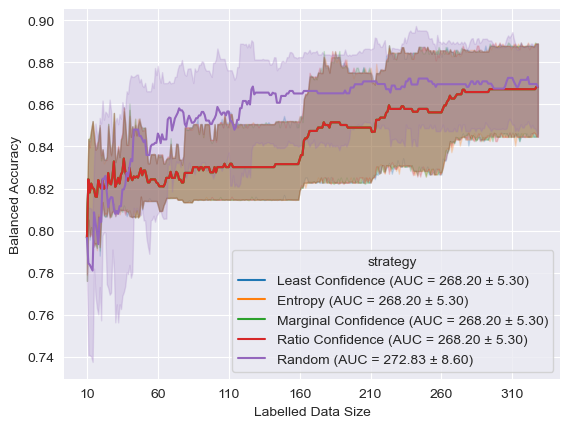

In [15]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)